# Barren Plateau: Overview through Pauli-Progation

This notebook shows how to study the gradient variance of a circuit's observable under the assumptions of
* Uniform random parameters $[0, 2\pi]$
* Gaussian random parameters $\mathcal{N}(0, \sigma)$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from scipy.optimize import curve_fit

from pprop.propagator import Propagator
from pprop.propagator.pruning import DeadQubitPruner, XYWeightPruner
from pprop.extra.bp import Uniform, Gaussian

plt.rcParams.update({'font.size': 13, 'axes.titlesize': 14, 'figure.dpi': 120})
rng = np.random.default_rng(seed=42)

/home/samonaco/Pauli-Propagator/.venv/lib/python3.12/site-packages/pennylane/operation.py:2622: PennyLaneDeprecationWarning: Observable is deprecated and will be removed in v0.43. A generic Operator class should be used instead. If defining an Operator, set the is_hermitian property to True. If checking if an Operator is Hermitian, check the is_hermitian property. 
  warnings.warn(


In [2]:
def make_he_ansatz(n_qubits: int, n_layers: int):
    """
    Hardware-efficient ansatz: d layers of (RY on each qubit) + (CNOT ring).
    Observable: Z on qubit 0.  Total parameters: n * d.
    """
    def ansatz(params):
        idx = 0
        for _ in range(n_layers):
            for q in range(n_qubits):
                qml.RY(params[idx], wires=q)
                idx += 1
            for q in range(n_qubits):
                qml.CNOT(wires=[q, (q + 1) % n_qubits])
            qml.Barrier()
        return [qml.expval(qml.PauliZ(0))]
    return ansatz

In [3]:
example_num_qubits = 4
example_num_layers = 2

print("Hardware-efficient ansatz:")
print(f" > num_qubits: {example_num_qubits}")
print(f" > num_layers: {example_num_layers}\n")
print(qml.draw(make_he_ansatz(example_num_qubits, example_num_layers))(qml.numpy.arange(100)))

Hardware-efficient ansatz:
 > num_qubits: 4
 > num_layers: 2

0: ──RY(0.00)─╭●───────╭X──||──RY(4.00)─╭●───────╭X──||─┤  <Z>
1: ──RY(1.00)─╰X─╭●────│───||──RY(5.00)─╰X─╭●────│───||─┤     
2: ──RY(2.00)────╰X─╭●─│───||──RY(6.00)────╰X─╭●─│───||─┤     
3: ──RY(3.00)───────╰X─╰●──||──RY(7.00)───────╰X─╰●──||─┤     


## 1. Uniform random parameters

Under uniform random parameters $\theta_k \sim \mathcal{U}[0, 2\pi]$, the gradient variance of the observable $\partial_{\theta_k}\langle Z_0\rangle$ is known to decay **exponentially** with the number of qubits - this is the barren plateau phenomenon. For a hardware-efficient ansatz with $n$ qubits and sufficiently many layers one expects

$$\mathrm{Var}\!\left[\partial_{\theta_k}\langle Z_0\rangle\right] \sim C \cdot 2^{-n}.$$

We verify this in two independent ways:

- **Analytically (Theorem 1):** the Pauli Propagator computes the exact expected gradient variance in closed form, with no sampling involved.
- **Numerically (direct sampling):** random parameter vectors are drawn from the uniform distribution and the variance is estimated empirically.

Both are plotted against the number of qubits $n$ at fixed depth $d$ and compared against a fitted $C \cdot 2^{-n}$ curve, confirming the exponential scaling.

In [4]:
N_QUBITS_RANGE = [2, 3, 4, 5, 6, 7, 8]
N_LAYERS       = 3

print(f"Sweeping n = {N_QUBITS_RANGE},  d = {N_LAYERS}\n")
print(f"{'n':>4} | {'Exact Var':>14}")
print("-" * 25)

exact_vars_n = []
samples_vars_mean_n = []
samples_vars_std_n = []

for n in N_QUBITS_RANGE:
    prop = Propagator(make_he_ansatz(n, N_LAYERS))
    prop.propagate()
    GV = Uniform(prop)
    sampled = GV.sampled()
    samples_vars_mean_n.append(sampled['mean'])
    samples_vars_std_n.append(sampled['std'])
    exact_vars_n.append(GV.average()['all'])

    print(f"{n:>4} | {exact_vars_n[-1]:>14.6e}")


Sweeping n = [2, 3, 4, 5, 6, 7, 8],  d = 3

   n |      Exact Var
-------------------------
   2 |   2.135417e-01
   3 |   1.111111e-01
   4 |   6.066895e-02
   5 |   3.058268e-02
   6 |   1.572673e-02
   7 |   8.843921e-03
   8 |   4.988069e-03


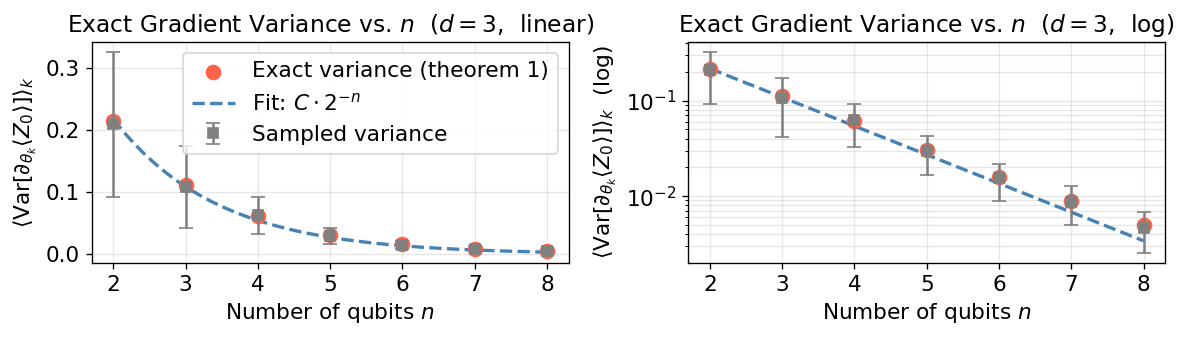

In [5]:
def exp_decay(n, C):
    return C * 2**(-np.asarray(n, dtype=float))

n_arr  = np.array(N_QUBITS_RANGE, dtype=float)
n_fine = np.linspace(n_arr[0], n_arr[-1], 300)

C_fit, _ = curve_fit(exp_decay, n_arr, exact_vars_n, p0=[3,])

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

for ax, yscale in zip(axes, ['linear', 'log']):
    ax.scatter(N_QUBITS_RANGE, exact_vars_n, color='tomato', s=70, zorder=5,
               label='Exact variance (theorem 1)')
    ax.errorbar(N_QUBITS_RANGE, samples_vars_mean_n, yerr=samples_vars_std_n,
            fmt='s', color='gray', capsize=4, lw=1.5, zorder=5,
            label='Sampled variance')
    ax.plot(n_fine, exp_decay(n_fine, C_fit), color='steelblue', lw=2, ls='--',
            label=f'Fit: $C \\cdot {2}^{{-n}}$')
    ax.set_yscale(yscale)
    ax.set_xlabel('Number of qubits $n$')
    ax.set_ylabel(
        r'$\langle\mathrm{Var}[\partial_{\theta_k}\langle Z_0\rangle]\rangle_k$'
        + ('' if yscale == 'linear' else '  (log)'))
    ax.set_title(f'Exact Gradient Variance vs. $n$  ($d={N_LAYERS}$,  {yscale})')
    if yscale == 'linear':
        ax.legend()
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Gaussian random parameters

We now consider Gaussian random parameters $\theta_k \sim \mathcal{N}(0, \sigma^2)$. Rather than varying the circuit size, we **fix the circuit** (8 qubits, 3 layers) and sweep the standard deviation $\sigma$.

The two limiting cases are clear:

- **$\sigma = 0$:** all parameters are zero, the circuit reduces to the identity (up to the CNOT structure), and the gradient variance is **zero** - there is no randomness to explore, so the expected squared gradient is zero.
- **$\sigma \to \infty$:** the Gaussian wraps densely around $[0, 2\pi]$ and the distribution converges to uniform, recovering the uniform barren-plateau result.

Between these limits we expect a non-trivial **peak**: at some intermediate $\sigma$ the spread of parameters resonates with the circuit, producing the highest achievable gradient variance before the barren plateau kicks in. The theorem provides the exact curve; direct sampling confirms it.

In [6]:
prop = Propagator(make_he_ansatz(8, 3))
print(prop)
prop.show()
prop.propagate(pruners=[XYWeightPruner(), DeadQubitPruner()])

Propagator
  Number of qubits : 8
  Trainable parameters : 24

0: ──RY(0.00)─╭●───────────────────╭X──||──RY(8.00)──╭●───────────────────╭X──||──RY(16.00)─╭● ···
1: ──RY(1.00)─╰X─╭●────────────────│───||──RY(9.00)──╰X─╭●────────────────│───||──RY(17.00)─╰X ···
2: ──RY(2.00)────╰X─╭●─────────────│───||──RY(10.00)────╰X─╭●─────────────│───||──RY(18.00)─── ···
3: ──RY(3.00)───────╰X─╭●──────────│───||──RY(11.00)───────╰X─╭●──────────│───||──RY(19.00)─── ···
4: ──RY(4.00)──────────╰X─╭●───────│───||──RY(12.00)──────────╰X─╭●───────│───||──RY(20.00)─── ···
5: ──RY(5.00)─────────────╰X─╭●────│───||──RY(13.00)─────────────╰X─╭●────│───||──RY(21.00)─── ···
6: ──RY(6.00)────────────────╰X─╭●─│───||──RY(14.00)────────────────╰X─╭●─│───||──RY(22.00)─── ···
7: ──RY(7.00)───────────────────╰X─╰●──||──RY(15.00)───────────────────╰X─╰●──||──RY(23.00)─── ···

0: ··· ───────────────────╭X──||─┤  <Z>
1: ··· ─╭●────────────────│───||─┤     
2: ··· ─╰X─╭●─────────────│───||─┤     
3: ··· ────╰X─╭●────────

In [7]:
sigmas = np.linspace(0, 2, 50)
sigmas_red = np.linspace(0, 1.5, 20)
sampled_normal = []
theorem_normal = []
for sigma in sigmas:
    GV = Gaussian(prop, sigma=sigma)
    theorem_normal.append(GV.average()['all'])
for sigma in sigmas_red:
    GV = Gaussian(prop, sigma=sigma)
    sampled_normal.append(GV.sampled(num_samples=500))


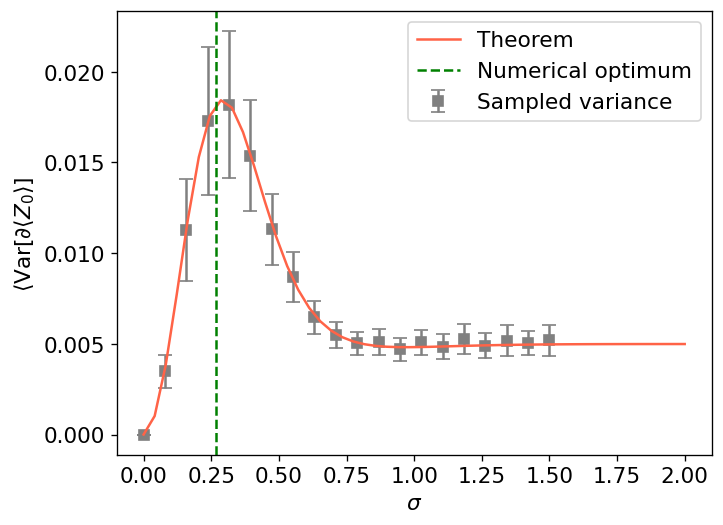

In [8]:
plt.errorbar(sigmas_red, [s['mean'] for s in sampled_normal], yerr=[s['std']/3 for s in sampled_normal],
        fmt='s', color='gray', capsize=4, lw=1.5, zorder=0,
        label='Sampled variance')
plt.plot(sigmas, theorem_normal, label='Theorem', color='tomato')
plt.axvline(x=GV.get_peak(), label='Numerical optimum', color='green', ls='--', lw=1.5)
plt.xlabel(r'$\sigma$')
plt.ylabel(r'$\langle\mathrm{Var}[\partial\langle Z_0\rangle]$')
plt.legend()